In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torch.utils.data import Dataset, random_split
from torchvision import datasets, transforms
import torch.nn.functional as F


Load the dataset

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [4]:
dataset=datasets.ImageFolder(root="../datasets/brain_tumor_dataset",transform=train_transform)

In [5]:
num_classes=len(dataset.classes)
print(num_classes)

2


Split the dataset

In [6]:
train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

In [7]:
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

In [8]:
train_data = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_data = DataLoader(val_dataset, batch_size=32, shuffle=False)

Train the data


In [9]:
import torchvision.models as models

model=models.densenet121(pretrained=True)
model.classifier = nn.Sequential(
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
for param in model.features.parameters():
    param.requires_grad = False

In [11]:
# Unfreeze last block
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

In [12]:
device="cpu"


optimizer = optim.Adam([
    {"params":model.features.denseblock1.parameters(), "lr":1e-4},
    {"params":model.classifier.parameters(), "lr":3e-4},
],weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)
class_weights = torch.tensor([1.0, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(class_weights)


In [13]:
model.train()
device = "cpu"
epochs = 35

for epoch in range(epochs):
    total = 0
    correct = 0
    running_loss = 0

    for images, labels in train_data:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_data)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Accuracy: {accuracy:.2f}%")


Epoch [1/35] Loss: 0.8991 Accuracy: 53.47%
Epoch [2/35] Loss: 0.6288 Accuracy: 66.83%
Epoch [3/35] Loss: 0.5284 Accuracy: 73.27%
Epoch [4/35] Loss: 0.4924 Accuracy: 81.19%
Epoch [5/35] Loss: 0.4234 Accuracy: 80.69%
Epoch [6/35] Loss: 0.4377 Accuracy: 77.72%
Epoch [7/35] Loss: 0.3692 Accuracy: 86.63%
Epoch [8/35] Loss: 0.3438 Accuracy: 87.13%
Epoch [9/35] Loss: 0.3173 Accuracy: 89.60%
Epoch [10/35] Loss: 0.2634 Accuracy: 88.61%
Epoch [11/35] Loss: 0.3308 Accuracy: 88.12%
Epoch [12/35] Loss: 0.2744 Accuracy: 87.62%
Epoch [13/35] Loss: 0.3074 Accuracy: 87.13%
Epoch [14/35] Loss: 0.2634 Accuracy: 89.11%
Epoch [15/35] Loss: 0.2884 Accuracy: 88.61%
Epoch [16/35] Loss: 0.3569 Accuracy: 89.11%
Epoch [17/35] Loss: 0.2735 Accuracy: 88.12%
Epoch [18/35] Loss: 0.2476 Accuracy: 88.61%
Epoch [19/35] Loss: 0.2748 Accuracy: 90.59%
Epoch [20/35] Loss: 0.2178 Accuracy: 91.09%
Epoch [21/35] Loss: 0.2060 Accuracy: 93.07%
Epoch [22/35] Loss: 0.2306 Accuracy: 91.09%
Epoch [23/35] Loss: 0.2329 Accuracy: 89.1

In [14]:
import torch.nn.functional as F

model.eval()

total = 0
correct = 0
running_loss = 0

threshold = 0.45  # adjust for recall/precision tradeoff

with torch.no_grad():
    for images, labels in val_data:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        probs = F.softmax(outputs, dim=1)
        yes_probs = probs[:, 1]

        preds = (yes_probs > threshold).long()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
avg_loss = running_loss / len(val_data)

print(f"Validation Loss: {avg_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")





Validation Loss: 0.4094
Validation Accuracy: 84.31%


In [15]:
torch.save(model.state_dict(), "best_model_brain_tumor.pth")

Metrices

In [16]:
from sklearn.metrics import confusion_matrix,classification_report

model.eval()
all_preds=[]
all_labels=[]
with torch.no_grad():
    for images,labels in (val_data):
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.cpu().numpy().ravel())
        all_labels.append(labels.cpu().numpy().ravel())


In [17]:
import numpy as np


all_preds=np.concatenate(all_preds)
all_labels=np.concatenate(all_labels)
print(type(all_preds[0]))
print(type(all_labels[0]))

<class 'numpy.int64'>
<class 'numpy.int64'>


In [18]:
print("Confusion Matrix:\n",confusion_matrix(all_labels,all_preds))
print("Classification Report:\n",classification_report(all_labels,all_preds))


Confusion Matrix:
 [[18  2]
 [ 5 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84        20
           1       0.93      0.84      0.88        31

    accuracy                           0.86        51
   macro avg       0.86      0.87      0.86        51
weighted avg       0.87      0.86      0.86        51



Prediction on images

In [19]:
model.load_state_dict(torch.load("best_model_brain_tumor.pth", map_location=device))
model.eval()
model.to(device)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225])

])

In [21]:
image_path="../datasets/test_MRI.png"
image=Image.open(image_path).convert("RGB")
org_image=image
image=transforms(image).unsqueeze(0)
image=image.to(device)

Probability of Yes: 0.80
Probability of No: 0.20
Brain Tumor Detected


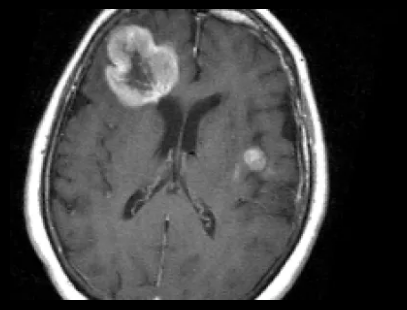

In [22]:


with torch.no_grad():
    outputs = model(image)
    proba=F.softmax(outputs, dim=1)

yes_probs=proba[0][1].item()
no_proba=proba[0][0].item()

plt.figure(figsize=(5,5))
plt.imshow(org_image)
plt.axis('off')

print(f"Probability of Yes: {yes_probs:.2f}"
      )
print(f"Probability of No: {no_proba:.2f}"
      )
threshold=0.45

if yes_probs > threshold:
    print("Brain Tumor Detected")
else:
    print("Brain Tumor Not Detected")


